# Proyecto Integrador de Data Science — Fase 1
## Relación entre las condiciones climáticas y el comportamiento de las ventas

**Pregunta de investigación:**  
¿En qué medida las condiciones climáticas, particularmente la temperatura y la precipitación, se relacionan con la cantidad de productos vendidos en los establecimientos comerciales durante el período de enero a septiembre de 2021?

**Objetivo general:** analizar la relación entre las condiciones climáticas y la cantidad de productos vendidos durante el período de estudio.

**Objetivos específicos**
1. Analizar el comportamiento de las ventas según fecha, local y sección de productos.
2. Determinar la relación entre temperatura, precipitación y cantidad vendida.
3. Evaluar, en las fases posteriores, la posibilidad de predecir el comportamiento de las ventas con clima y otras variables disponibles.

> **Alcance:** esta notebook corresponde a la Fase 1. Describe, limpia, transforma e integra exploratoriamente los datos y genera hipótesis preliminares. No realiza contrastes inferenciales ni modelado predictivo definitivo.

## Metodología y unidad de análisis

La Fase 1 sigue CRISP-DM: comprensión del problema, comprensión de los datos, preparación, análisis exploratorio y comunicación.

La unidad original es el **registro de venta de un producto en un local en una fecha**. Para integrar el clima de referencia y analizar el fenómeno a una escala comparable, se construyen dos niveles agregados:

- **diario:** fecha → cantidad total;
- **diario por local:** fecha + local → cantidad total.

La cátedra exige que las transformaciones sean reproducibles por código, que las decisiones de limpieza estén documentadas y que el notebook pueda ejecutarse de principio a fin.

In [1]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

from pathlib import Path
import os
import math
import warnings
import hashlib
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

# ============================================================
# ESTRUCTURA DEL PROYECTO
# ============================================================

# La notebook está dentro de /notebooks,
# por lo tanto la raíz del proyecto es la carpeta padre.
ROOT = Path.cwd().parent

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Crear carpetas si no existen
for folder in [
    RAW_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    TABLES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# ============================================================
# ARCHIVO ORIGINAL PROPORCIONADO POR LA CÁTEDRA
# ============================================================

CSV_PATH = RAW_DIR / "ventas.csv"

# ============================================================
# PARÁMETROS DEL ANÁLISIS
# ============================================================

FECHA_INICIO = pd.Timestamp("2021-01-02")
FECHA_FIN = pd.Timestamp("2021-09-30")

CHUNK_SIZE = 200_000

USECOLS = [
    "fecha_vta",
    "local",
    "desc_producto",
    "desc_secciones",
    "desc_sub_secciones",
    "desc_categoria",
    "desc_marca",
    "cantidad"
]

TEXT_COLS = [
    "local",
    "desc_producto",
    "desc_secciones",
    "desc_sub_secciones",
    "desc_categoria",
    "desc_marca"
]

# ============================================================
# VERIFICACIÓN DE CONFIGURACIÓN
# ============================================================

print("Directorio raíz:", ROOT)
print("CSV:", CSV_PATH)
print("Existe:", CSV_PATH.exists())
print("Período:", FECHA_INICIO.date(), "a", FECHA_FIN.date())

Directorio raíz: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science
CSV: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\raw\ventas.csv
Existe: True
Período: 2021-01-02 a 2021-09-30


## Configuración climática — ubicación meteorológica de referencia

El archivo de ventas proporcionado por la cátedra identifica los establecimientos únicamente como `Local X` y `Local Y` y **no contiene coordenadas ni una ubicación geográfica verificable**. Por lo tanto, no es metodológicamente válido inventar una coordenada distinta para cada local.

Para poder completar el objetivo académico de estudiar la relación entre ventas y clima, se adopta una **ubicación meteorológica de referencia única: Asunción, Paraguay**. Esta ubicación **no se interpreta como la ubicación real de Local X o Local Y**. Se utiliza únicamente para obtener una serie climática diaria común durante el período de estudio.

Esta decisión debe quedar explicitada como una **limitación del análisis**: el estudio permite evaluar asociaciones temporales entre ventas y condiciones meteorológicas de referencia, pero no permite atribuir diferencias entre locales a diferencias climáticas espaciales.

La fuente climática será **Open-Meteo Historical Weather API**, que permite consultar datos históricos diarios por coordenadas. Se utilizarán:

- temperatura media diaria;
- temperatura máxima diaria;
- temperatura mínima diaria;
- precipitación acumulada diaria;
- humedad relativa media diaria como variable adicional.

Fuente: https://open-meteo.com/en/docs/historical-weather-api


In [2]:
# ============================================================
# CONFIGURACIÓN DE UBICACIÓN METEOROLÓGICA DE REFERENCIA
# ============================================================
# IMPORTANTE:
# Estas coordenadas NO representan necesariamente a Local X ni Local Y.
# Se utilizan como ubicación meteorológica de referencia para el estudio.
#
# Referencia geográfica: Asunción, Paraguay.
# Coordenadas aproximadas del centro urbano:
# latitud  = -25.2637
# longitud = -57.5759

REFERENCE_LOCATION = {
    "nombre": "Asunción, Paraguay",
    "lat": -25.2637,
    "lon": -57.5759
}

print("Ubicación meteorológica de referencia:", REFERENCE_LOCATION["nombre"])
print("Latitud:", REFERENCE_LOCATION["lat"])
print("Longitud:", REFERENCE_LOCATION["lon"])
print()
print("ADVERTENCIA METODOLÓGICA:")
print("La ubicación de referencia NO se atribuye como ubicación real de Local X o Local Y.")
print("Se utilizará una única serie climática diaria y se relacionará con las ventas por fecha.")


Ubicación meteorológica de referencia: Asunción, Paraguay
Latitud: -25.2637
Longitud: -57.5759

ADVERTENCIA METODOLÓGICA:
La ubicación de referencia NO se atribuye como ubicación real de Local X o Local Y.
Se utilizará una única serie climática diaria y se relacionará con las ventas por fecha.


## 3. Comprensión y selección de los datos

In [3]:
# ============================================================
# 3.1 INSPECCIÓN INICIAL
# ============================================================
if not CSV_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {CSV_PATH}")

muestra = pd.read_csv(CSV_PATH, nrows=10, low_memory=False)

print("Cantidad de columnas:", len(muestra.columns))
print("\nColumnas:")
for i, col in enumerate(muestra.columns):
    print(f"{i}: {col}")

print("\nTipos detectados:")
display(muestra.dtypes.to_frame("tipo"))

print("\nMuestra:")
display(muestra)

Cantidad de columnas: 8

Columnas:
0: fecha_vta
1: local
2: desc_producto
3: desc_secciones
4: desc_sub_secciones
5: desc_categoria
6: desc_marca
7: cantidad

Tipos detectados:


,tipo
fecha_vta,object
local,object
desc_producto,object
desc_secciones,object
desc_sub_secciones,object
desc_categoria,object
desc_marca,object
cantidad,float64



Muestra:


,fecha_vta,local,desc_producto,desc_secciones,desc_sub_secciones,desc_categoria,desc_marca,cantidad
0,2021-01-02,Local X,PASTA PORA ÑOQUIS DE HUEVO 400 GRS.,Perecederos,Pastas Frescas,Nacional,PASTA PORA,1.0
1,2021-01-02,Local X,PASTA PORA ÑOQUIS DE HUEVO 400 GRS.,Perecederos,Pastas Frescas,Nacional,PASTA PORA,1.0
2,2021-01-02,Local X,PASTA PORA ÑOQUIS DE HUEVO 400 GRS.,Perecederos,Pastas Frescas,Nacional,PASTA PORA,1.0
3,2021-01-02,Local X,SAN LOREN BEBIDA LACT. ULTRA 1 LITRO,Perecederos,Lacteos,Sachet,San Loren,4.0
4,2021-01-02,Local X,SAN LOREN BEBIDA LACT FORTIF LIGHT ULTRA 1LT*,Perecederos,Lacteos,Sachet,San Loren,4.0
5,2021-01-02,Local X,CUCHARON MELAMINA C/DISEÑO 33CM REF 35686-96,Bazar,Bazar,Utensilio,35686,1.0
6,2021-01-02,Local X,C2 TOCADOR 130GRS AZUL FRESH *60,Belleza y Salud,Belleza y Salud,Jabon de tocador,C2,1.0
7,2021-01-02,Local X,C2 TOCADOR 130GRS VERDE CITRUS *60,Belleza y Salud,Belleza y Salud,Jabon de tocador,C2,1.0
8,2021-01-02,Local X,C2 TOCADOR 130GRS ROSA ROMANCE *60,Belleza y Salud,Belleza y Salud,Jabon de tocador,C2,1.0
9,2021-01-02,Local X,SAN LOREN BEBIDA LACTEA LIGHT COCO 1LT,Perecederos,Lacteos,sin asignar.,San Loren,1.0


### Selección

Se conserva el período completo disponible de la propuesta: **2 de enero a 30 de septiembre de 2021**. Se conservan las variables de fecha, local, producto, jerarquía comercial, marca y cantidad porque permiten responder los objetivos descriptivos y preparar la integración climática.

No se elimina información de producto solo por tener valores faltantes: primero se cuantifica y se evalúa su utilidad.

In [4]:
# ============================================================
# 3.2 PERFILADO COMPLETO POR BLOQUES
# ============================================================
total_filas = 0
filas_periodo = 0
nulos = pd.Series(0, index=USECOLS, dtype="int64")
suma_periodo = 0.0
min_fecha = None
max_fecha = None

cardinalidad_sets = {c: set() for c in TEXT_COLS}

for chunk in pd.read_csv(
    CSV_PATH,
    usecols=USECOLS,
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    total_filas += len(chunk)
    nulos = nulos.add(chunk.isna().sum().astype("int64"), fill_value=0).astype("int64")

    fechas = pd.to_datetime(chunk["fecha_vta"], errors="coerce")
    cantidad = pd.to_numeric(chunk["cantidad"], errors="coerce")

    valid = fechas.notna()
    if valid.any():
        cmin, cmax = fechas[valid].min(), fechas[valid].max()
        min_fecha = cmin if min_fecha is None else min(min_fecha, cmin)
        max_fecha = cmax if max_fecha is None else max(max_fecha, cmax)

    periodo = fechas.between(FECHA_INICIO, FECHA_FIN)
    filas_periodo += int(periodo.sum())
    suma_periodo += float(cantidad.loc[periodo].sum())

    for col in TEXT_COLS:
        cardinalidad_sets[col].update(
            chunk[col].dropna().astype("string").str.strip().unique().tolist()
        )

perfil = pd.DataFrame({
    "variable": USECOLS,
    "faltantes": [int(nulos[c]) for c in USECOLS]
})
perfil["% faltantes"] = perfil["faltantes"] / total_filas * 100

print(f"Filas totales: {total_filas:,}")
print(f"Filas en período: {filas_periodo:,}")
print(f"Fecha mínima: {min_fecha}")
print(f"Fecha máxima: {max_fecha}")
print(f"Cantidad total en período: {suma_periodo:,.2f}")

display(perfil)

cardinalidad = pd.DataFrame({
    "campo": TEXT_COLS,
    "valores_unicos": [len(cardinalidad_sets[c]) for c in TEXT_COLS]
})
display(cardinalidad)

Filas totales: 9,447,662
Filas en período: 9,447,662
Fecha mínima: 2021-01-02 00:00:00
Fecha máxima: 2021-09-30 00:00:00
Cantidad total en período: 11,158,206.72


,variable,faltantes,% faltantes
0,fecha_vta,0,0.000000
1,local,0,0.000000
2,desc_producto,6,0.000064
3,desc_secciones,6,0.000064
4,desc_sub_secciones,6,0.000064
5,desc_categoria,6,0.000064
6,desc_marca,6,0.000064
7,cantidad,0,0.000000


,campo,valores_unicos
0,local,2
1,desc_producto,38907
2,desc_secciones,12
3,desc_sub_secciones,103
4,desc_categoria,1186
5,desc_marca,2835


In [5]:
# ============================================================
# 3.3 DICCIONARIO DE DATOS ORIGINAL
# ============================================================
diccionario_original = pd.DataFrame([
    ["fecha_vta", "Fecha del movimiento/venta", "temporal", "fecha", "2021-01-02 a 2021-09-30", nulos["fecha_vta"]/total_filas*100],
    ["local", "Establecimiento donde se registra el movimiento", "categórica", "identificador/nombre", f"{cardinalidad_sets['local']}", nulos["local"]/total_filas*100],
    ["desc_producto", "Descripción del producto", "categórica", "texto", f"{len(cardinalidad_sets['desc_producto']):,} categorías", nulos["desc_producto"]/total_filas*100],
    ["desc_secciones", "Sección comercial", "categórica", "texto", f"{len(cardinalidad_sets['desc_secciones']):,} categorías", nulos["desc_secciones"]/total_filas*100],
    ["desc_sub_secciones", "Subsección comercial", "categórica", "texto", f"{len(cardinalidad_sets['desc_sub_secciones']):,} categorías", nulos["desc_sub_secciones"]/total_filas*100],
    ["desc_categoria", "Categoría del producto", "categórica", "texto", f"{len(cardinalidad_sets['desc_categoria']):,} categorías", nulos["desc_categoria"]/total_filas*100],
    ["desc_marca", "Marca del producto", "categórica", "texto", f"{len(cardinalidad_sets['desc_marca']):,} categorías", nulos["desc_marca"]/total_filas*100],
    ["cantidad", "Cantidad registrada en el movimiento", "numérica", "unidades/medida registrada", "variable continua/discreta según producto", nulos["cantidad"]/total_filas*100],
], columns=["campo","descripción","tipo","unidad","rango/categorías","% faltantes"])

display(diccionario_original)
diccionario_original.to_csv(TABLES_DIR / "diccionario_datos_original.csv", index=False)

,campo,descripción,tipo,unidad,rango/categorías,% faltantes
0,fecha_vta,Fecha del movimiento/venta,temporal,fecha,2021-01-02 a 2021-09-30,0.000000
1,local,Establecimiento donde se registra el movimiento,categórica,identificador/nombre,"{'Local Y', 'Local X'}",0.000000
2,desc_producto,Descripción del producto,categórica,texto,"38,907 categorías",0.000064
3,desc_secciones,Sección comercial,categórica,texto,12 categorías,0.000064
4,desc_sub_secciones,Subsección comercial,categórica,texto,103 categorías,0.000064
5,desc_categoria,Categoría del producto,categórica,texto,"1,186 categorías",0.000064
6,desc_marca,Marca del producto,categórica,texto,"2,835 categorías",0.000064
7,cantidad,Cantidad registrada en el movimiento,numérica,unidades/medida registrada,variable continua/discreta según producto,0.000000


## 4. Evaluación de calidad

In [6]:
# ============================================================
# 4.1 CALIDAD: FECHAS, CANTIDAD Y FALTANTES
# ============================================================
fechas_invalidas = 0
fechas_fuera_rango = 0
cantidad_no_numerica = 0
cantidad_negativa = 0
cantidad_cero = 0
cantidad_min = np.inf
cantidad_max = -np.inf
suma_cantidad = 0.0
n_cantidad = 0

faltantes_por_columna = pd.Series(0, index=USECOLS, dtype="int64")

for chunk in pd.read_csv(CSV_PATH, usecols=USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
    faltantes_por_columna = faltantes_por_columna.add(
        chunk.isna().sum().astype("int64"), fill_value=0
    ).astype("int64")

    fechas = pd.to_datetime(chunk["fecha_vta"], errors="coerce")
    cantidad = pd.to_numeric(chunk["cantidad"], errors="coerce")

    fechas_invalidas += int(fechas.isna().sum())
    fechas_fuera_rango += int((~fechas.isna() & ~fechas.between(FECHA_INICIO, FECHA_FIN)).sum())
    cantidad_no_numerica += int(cantidad.isna().sum())
    cantidad_negativa += int((cantidad < 0).sum())
    cantidad_cero += int((cantidad == 0).sum())

    if cantidad.notna().any():
        cantidad_min = min(cantidad_min, cantidad.min())
        cantidad_max = max(cantidad_max, cantidad.max())
        suma_cantidad += float(cantidad.sum())
        n_cantidad += int(cantidad.notna().sum())

cantidad_media = suma_cantidad / n_cantidad

resumen_calidad = pd.DataFrame({
    "indicador": [
        "Registros totales", "Fechas inválidas", "Fechas fuera del período",
        "Cantidad no numérica", "Cantidad negativa", "Cantidad igual a cero",
        "Mínimo cantidad", "Máximo cantidad", "Media cantidad"
    ],
    "resultado": [
        total_filas, fechas_invalidas, fechas_fuera_rango,
        cantidad_no_numerica, cantidad_negativa, cantidad_cero,
        cantidad_min, cantidad_max, cantidad_media
    ]
})
display(resumen_calidad)

,indicador,resultado
0,Registros totales,9.447662e+06
1,Fechas inválidas,0.000000e+00
2,Fechas fuera del período,0.000000e+00
3,Cantidad no numérica,0.000000e+00
4,Cantidad negativa,6.752300e+04
5,Cantidad igual a cero,0.000000e+00
6,Mínimo cantidad,-4.050000e+04
7,Máximo cantidad,4.050000e+04
8,Media cantidad,1.181055e+00


### Decisiones iniciales de calidad

- Los **6 registros con faltantes descriptivos** se conservan porque mantienen fecha, local y cantidad.
- Las **cantidades negativas no se eliminan automáticamente**: pueden representar devoluciones, anulaciones o ajustes.
- Los **ceros** se conservan si existen, porque no constituyen por sí mismos un error.
- No se eliminan valores extremos sin evidencia de que sean errores.

In [7]:
# ============================================================
# 4.2 INSPECCIÓN DE REGISTROS CON FALTANTES
# ============================================================
registros_faltantes = []

for chunk in pd.read_csv(CSV_PATH, usecols=USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
    filas = chunk[chunk.isna().any(axis=1)]
    if not filas.empty:
        registros_faltantes.append(filas)

registros_faltantes = (
    pd.concat(registros_faltantes, ignore_index=True)
    if registros_faltantes else pd.DataFrame(columns=USECOLS)
)

print("Registros con al menos un faltante:", len(registros_faltantes))
display(registros_faltantes)

Registros con al menos un faltante: 6


,fecha_vta,local,desc_producto,desc_secciones,desc_sub_secciones,desc_categoria,desc_marca,cantidad
0,2021-02-20,Local X,NaN,NaN,NaN,NaN,NaN,1.00
1,2021-02-20,Local X,NaN,NaN,NaN,NaN,NaN,-1.00
2,2021-07-11,Local X,NaN,NaN,NaN,NaN,NaN,0.65
3,2021-07-11,Local X,NaN,NaN,NaN,NaN,NaN,-0.65
4,2021-07-30,Local X,NaN,NaN,NaN,NaN,NaN,1.00
5,2021-07-30,Local X,NaN,NaN,NaN,NaN,NaN,-1.00


In [8]:
# ============================================================
# 4.3 DUPLICADOS EXACTOS GLOBALES
# ============================================================
# El cálculo por chunks no sirve para duplicados globales.
# Por eso se comparan hashes de filas en todo el archivo.

hashes_filas = []

for chunk in pd.read_csv(CSV_PATH, usecols=USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
    hashes_filas.append(
        pd.util.hash_pandas_object(chunk, index=False).to_numpy(dtype="uint64")
    )

todos_los_hashes = np.concatenate(hashes_filas)
hashes_unicos, frecuencias = np.unique(todos_los_hashes, return_counts=True)

grupos_duplicados = int((frecuencias > 1).sum())
filas_duplicadas_adicionales = int(np.sum(frecuencias[frecuencias > 1] - 1))

print(f"Grupos de filas repetidas: {grupos_duplicados:,}")
print(f"Filas adicionales en esos grupos: {filas_duplicadas_adicionales:,}")
print(f"Porcentaje de filas adicionales: {filas_duplicadas_adicionales/total_filas*100:.2f}%")

print("\nDecisión: NO eliminar duplicados exactos automáticamente.")
print("Motivo: no existe identificador de transacción y filas idénticas pueden representar movimientos distintos.")

Grupos de filas repetidas: 1,337,516
Filas adicionales en esos grupos: 4,335,413
Porcentaje de filas adicionales: 45.89%

Decisión: NO eliminar duplicados exactos automáticamente.
Motivo: no existe identificador de transacción y filas idénticas pueden representar movimientos distintos.


In [9]:
# ============================================================
# 4.4 REPETICIONES PARCIALES
# ============================================================
# Se agrupa globalmente después de concatenar los conteos parciales.
# Así se evita interpretar cada chunk como si fuera un universo independiente.

columnas_parcial = ["fecha_vta", "local", "desc_producto"]
partes_parciales = []

for chunk in pd.read_csv(CSV_PATH, usecols=columnas_parcial, chunksize=CHUNK_SIZE, low_memory=False):
    g = (
        chunk.groupby(columnas_parcial, dropna=False)
        .size()
        .reset_index(name="veces_en_chunk")
    )
    partes_parciales.append(g)

repeticiones_parciales = (
    pd.concat(partes_parciales, ignore_index=True)
    .groupby(columnas_parcial, dropna=False)["veces_en_chunk"]
    .sum()
    .reset_index(name="veces_repetido")
)

repeticiones_parciales = repeticiones_parciales[
    repeticiones_parciales["veces_repetido"] > 1
].sort_values("veces_repetido", ascending=False)

print("Combinaciones fecha + local + producto repetidas:", len(repeticiones_parciales))
display(repeticiones_parciales.head(15))

Combinaciones fecha + local + producto repetidas: 1014822


,fecha_vta,local,desc_producto,veces_repetido
1395218,2021-07-03,Local X,"MT BOLSA GRANDE X UN,,,,",1934
1404626,2021-07-04,Local X,"MT BOLSA GRANDE X UN,,,,",1853
1610084,2021-08-01,Local X,"MT BOLSA GRANDE X UN,,,,",1796
1599976,2021-07-31,Local X,"MT BOLSA GRANDE X UN,,,,",1780
1504935,2021-07-18,Local X,"MT BOLSA GRANDE X UN,,,,",1716
1455607,2021-07-11,Local X,"MT BOLSA GRANDE X UN,,,,",1701
1554777,2021-07-25,Local X,"MT BOLSA GRANDE X UN,,,,",1649
1857606,2021-09-04,Local X,"MT BOLSA GRANDE X UN,,,,",1634
1495877,2021-07-17,Local X,"MT BOLSA GRANDE X UN,,,,",1634
1545809,2021-07-24,Local X,"MT BOLSA GRANDE X UN,,,,",1602


### Tratamiento de duplicados

Las repeticiones parciales no se consideran errores por sí mismas. Se verificó que una misma combinación de fecha, local y producto puede aparecer muchas veces con cantidades distintas. Sin un identificador transaccional no es posible demostrar que esas filas sean duplicaciones indebidas.

**Decisión:** conservarlas y documentar la limitación.

## 5. Limpieza y transformación reproducible

In [10]:
# ============================================================
# 5.1 GENERACIÓN DEL DATASET LIMPIO
# ============================================================
# Se normalizan fechas, cantidades y espacios en textos.
# No se eliminan negativos, duplicados ni outliers automáticamente.

CLEAN_PATH = PROCESSED_DIR / "ventas_limpias.csv"

if CLEAN_PATH.exists():
    CLEAN_PATH.unlink()

primera_escritura = True
filas_limpias = 0

for chunk in pd.read_csv(CSV_PATH, usecols=USECOLS, chunksize=CHUNK_SIZE, low_memory=False):
    chunk["fecha_vta"] = pd.to_datetime(chunk["fecha_vta"], errors="coerce")
    chunk["cantidad"] = pd.to_numeric(chunk["cantidad"], errors="coerce")

    for col in TEXT_COLS:
        chunk[col] = chunk[col].astype("string").str.strip()

    # Conservamos solo el alcance temporal definido y cantidades válidas.
    chunk = chunk[
        chunk["fecha_vta"].between(FECHA_INICIO, FECHA_FIN)
        & chunk["cantidad"].notna()
    ].copy()

    filas_limpias += len(chunk)

    chunk.to_csv(
        CLEAN_PATH,
        mode="w" if primera_escritura else "a",
        header=primera_escritura,
        index=False
    )
    primera_escritura = False

print("Dataset limpio generado:", CLEAN_PATH)
print("Filas conservadas:", f"{filas_limpias:,}")
print("¿Existe?:", CLEAN_PATH.exists())

Dataset limpio generado: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\processed\ventas_limpias.csv
Filas conservadas: 9,447,662
¿Existe?: True


In [11]:
# ============================================================
# 5.2 BITÁCORA DE LIMPIEZA
# ============================================================
cleaning_log = pd.DataFrame([
    ["fecha_vta", "Conversión a datetime", total_filas, "Normalizar fechas", "pd.to_datetime(errors='coerce')"],
    ["cantidad", "Conversión a numérico", total_filas, "Permitir análisis y agregación", "pd.to_numeric(errors='coerce')"],
    ["texto", "strip de espacios", total_filas, "Evitar categorías duplicadas por formato", "astype('string').str.strip()"],
    ["fecha_vta", "Filtro temporal", total_filas - filas_limpias, "Restringir al período definido", "between(FECHA_INICIO, FECHA_FIN)"],
    ["faltantes descriptivos", "Conservación explícita", len(registros_faltantes), "Mantener fecha/local/cantidad sin inventar categorías", "No imputar"],
    ["duplicados exactos", "Conservación", filas_duplicadas_adicionales, "Sin ID transaccional no puede probarse que sean errores", "No drop_duplicates()"],
    ["cantidad negativa", "Conservación", cantidad_negativa, "Puede representar devolución, anulación o ajuste", "No eliminar automáticamente"],
    ["valores extremos", "Conservación", None, "IQR no es discriminante en esta distribución y no demuestra error", "Revisión contextual"],
], columns=["variable","transformación/decisión","registros_afectados","motivo","método"])

display(cleaning_log)
cleaning_log.to_csv(TABLES_DIR / "bitacora_limpieza.csv", index=False)

,variable,transformación/decisión,registros_afectados,motivo,método
0,fecha_vta,Conversión a datetime,9447662.0,Normalizar fechas,pd.to_datetime(errors='coerce')
1,cantidad,Conversión a numérico,9447662.0,Permitir análisis y agregación,pd.to_numeric(errors='coerce')
2,texto,strip de espacios,9447662.0,Evitar categorías duplicadas por formato,astype('string').str.strip()
3,fecha_vta,Filtro temporal,0.0,Restringir al período definido,"between(FECHA_INICIO, FECHA_FIN)"
4,faltantes descriptivos,Conservación explícita,6.0,Mantener fecha/local/cantidad sin inventar cat...,No imputar
5,duplicados exactos,Conservación,4335413.0,Sin ID transaccional no puede probarse que sea...,No drop_duplicates()
6,cantidad negativa,Conservación,67523.0,"Puede representar devolución, anulación o ajuste",No eliminar automáticamente
7,valores extremos,Conservación,NaN,IQR no es discriminante en esta distribución y...,Revisión contextual


## 6. Valores atípicos e inconsistencias

In [12]:
# ============================================================
# 6.1 NEGATIVOS Y EXTREMOS
# ============================================================
negativos = pd.read_csv(
    CLEAN_PATH,
    usecols=["fecha_vta","local","desc_producto","desc_secciones","desc_categoria","cantidad"],
    low_memory=False
)
negativos = negativos[negativos["cantidad"] < 0]

positivos = pd.read_csv(
    CLEAN_PATH,
    usecols=["fecha_vta","local","desc_producto","desc_secciones","desc_categoria","cantidad"],
    low_memory=False
)
positivos = positivos[positivos["cantidad"] > 0]

negativos_extremos = negativos.nsmallest(20, "cantidad")
positivos_extremos = positivos.nlargest(20, "cantidad")

print("Negativos:", len(negativos))
print("Positivos:", len(positivos))
print("\nNegativos extremos:")
display(negativos_extremos)
print("\nPositivos extremos:")
display(positivos_extremos)

Negativos: 67523
Positivos: 9380139

Negativos extremos:


,fecha_vta,local,desc_producto,desc_secciones,desc_categoria,cantidad
7147080,2021-07-23,Local X,SERVICIOS VARIOS,Servicios,sin asignar.,-40500.0
1751420,2021-02-19,Local X,CEBOLLITA HOJA MAZO,Perecederos,Verdeo,-29039.0
6158198,2021-06-24,Local X,ESPINACA BLANCA,Perecederos,Verdeo,-29018.0
2309099,2021-03-06,Local X,ARCO IRIS OREGANO 10 GR *20,Almacen,sin asignar.,-20205.0
640556,2021-01-18,Local Y,BANANA KARAPE X KL(PICADO),Perecederos,Bananas,-19850.0
5817727,2021-06-13,Local X,MAIZ TUPI MOLIDO X KG,Almacen,Tupi,-11000.0
1873339,2021-02-22,Local X,AFRECHO DE TRIGO X KG,Almacen,Chanchos,-10895.0
1838208,2021-02-21,Local X,MANDIOCA X KG.,Perecederos,Mandioca,-10580.0
1040493,2021-01-30,Local X,FELIPITO X KG.,Produccion,Frescos,-10380.0
2037145,2021-02-27,Local X,FELIPITO X KG.,Produccion,Frescos,-10380.0



Positivos extremos:


,fecha_vta,local,desc_producto,desc_secciones,desc_categoria,cantidad
7147079,2021-07-23,Local X,SERVICIOS VARIOS,Servicios,sin asignar.,40500.0
1751419,2021-02-19,Local X,CEBOLLITA HOJA MAZO,Perecederos,Verdeo,29039.0
6158196,2021-06-24,Local X,ESPINACA BLANCA,Perecederos,Verdeo,29018.0
2309098,2021-03-06,Local X,ARCO IRIS OREGANO 10 GR *20,Almacen,sin asignar.,20205.0
640554,2021-01-18,Local Y,BANANA KARAPE X KL(PICADO),Perecederos,Bananas,19850.0
5817726,2021-06-13,Local X,MAIZ TUPI MOLIDO X KG,Almacen,Tupi,11000.0
1873338,2021-02-22,Local X,AFRECHO DE TRIGO X KG,Almacen,Chanchos,10895.0
1838211,2021-02-21,Local X,MANDIOCA X KG.,Perecederos,Mandioca,10580.0
1040492,2021-01-30,Local X,FELIPITO X KG.,Produccion,Frescos,10380.0
2037144,2021-02-27,Local X,FELIPITO X KG.,Produccion,Frescos,10380.0


In [13]:
# ============================================================
# 6.2 IQR EXPLORATORIO
# ============================================================
cantidades = pd.concat([positivos["cantidad"], negativos["cantidad"]], ignore_index=True)

q1 = cantidades.quantile(.25)
q3 = cantidades.quantile(.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers_iqr = cantidades[(cantidades < limite_inf) | (cantidades > limite_sup)]

print(f"Q1: {q1:.3f}")
print(f"Q3: {q3:.3f}")
print(f"IQR: {iqr:.3f}")
print(f"Límite inferior: {limite_inf:.3f}")
print(f"Límite superior: {limite_sup:.3f}")
print(f"Candidatos según IQR: {len(outliers_iqr):,} ({len(outliers_iqr)/len(cantidades)*100:.2f}%)")

if iqr == 0:
    print("\nInterpretación: Q1 y Q3 coinciden; por ello el IQR no discrimina adecuadamente esta variable.")
print("Decisión: los candidatos IQR NO se eliminan automáticamente.")

Q1: 1.000
Q3: 1.000
IQR: 0.000
Límite inferior: 1.000
Límite superior: 1.000
Candidatos según IQR: 4,384,787 (46.41%)

Interpretación: Q1 y Q3 coinciden; por ello el IQR no discrimina adecuadamente esta variable.
Decisión: los candidatos IQR NO se eliminan automáticamente.


In [14]:
# ============================================================
# 6.3 SIMETRÍA DE EXTREMOS
# ============================================================
extremos = pd.concat([negativos_extremos, positivos_extremos], ignore_index=True)
freq_magnitudes = extremos["cantidad"].abs().value_counts()

print("Magnitudes extremas repetidas en signo positivo/negativo:")
display(freq_magnitudes[freq_magnitudes > 1].head(20).to_frame("frecuencia"))

print(
    "\nInterpretación: la presencia de magnitudes positivas y negativas equivalentes "
    "es compatible con movimientos de reversión/ajuste, aunque el archivo no permite "
    "confirmar el motivo transaccional. Por ello se conservan."
)

Magnitudes extremas repetidas en signo positivo/negativo:


,frecuencia
cantidad,
9039.0,10
10035.0,6
10380.0,4
29039.0,2
40500.0,2
19850.0,2
20205.0,2
29018.0,2
11000.0,2



Interpretación: la presencia de magnitudes positivas y negativas equivalentes es compatible con movimientos de reversión/ajuste, aunque el archivo no permite confirmar el motivo transaccional. Por ello se conservan.


## 7. Variables derivadas y dataset analítico

Para el análisis descriptivo se agregan las cantidades a nivel diario y diario por local. Se crean variables de calendario: año, mes, nombre del mes, día de semana y fin de semana.

Estas variables son necesarias para separar patrones de calendario de la posible asociación climática.

In [15]:
# ============================================================
# 7.1 AGREGACIÓN DIARIA Y DIARIA POR LOCAL
# ============================================================
daily_parts = []
daily_store_parts = []

for chunk in pd.read_csv(CLEAN_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunk["fecha_vta"] = pd.to_datetime(chunk["fecha_vta"], errors="coerce")

    d = chunk.groupby("fecha_vta", as_index=False)["cantidad"].sum()
    ds = chunk.groupby(["fecha_vta","local"], as_index=False)["cantidad"].sum()

    daily_parts.append(d)
    daily_store_parts.append(ds)

daily = (
    pd.concat(daily_parts, ignore_index=True)
    .groupby("fecha_vta", as_index=False)["cantidad"].sum()
    .sort_values("fecha_vta")
)

daily_store = (
    pd.concat(daily_store_parts, ignore_index=True)
    .groupby(["fecha_vta","local"], as_index=False)["cantidad"].sum()
    .sort_values(["fecha_vta","local"])
)

for frame in [daily, daily_store]:
    frame["año"] = frame["fecha_vta"].dt.year
    frame["mes"] = frame["fecha_vta"].dt.month
    frame["mes_nombre"] = frame["fecha_vta"].dt.month_name()
    frame["día_semana"] = frame["fecha_vta"].dt.day_name()
    frame["fin_de_semana"] = frame["fecha_vta"].dt.dayofweek >= 5

daily["media_movil_7"] = daily["cantidad"].rolling(7, min_periods=1).mean()

daily.to_csv(PROCESSED_DIR / "ventas_diarias.csv", index=False)
daily_store.to_csv(PROCESSED_DIR / "ventas_diarias_por_local.csv", index=False)

print("Días:", len(daily))
print("Registros fecha-local:", len(daily_store))
display(daily.head())

Días: 271
Registros fecha-local: 540


,fecha_vta,cantidad,año,mes,mes_nombre,día_semana,fin_de_semana,media_movil_7
0,2021-01-02,49828.3137,2021,1,January,Saturday,True,49828.313700
1,2021-01-03,47241.1441,2021,1,January,Sunday,True,48534.728900
2,2021-01-04,55018.2621,2021,1,January,Monday,False,50695.906633
3,2021-01-05,49574.9965,2021,1,January,Tuesday,False,50415.679100
4,2021-01-06,37930.7416,2021,1,January,Wednesday,False,47918.691600


## 8. Análisis univariado

In [16]:
# ============================================================
# 8.1 ESTADÍSTICA DESCRIPTIVA
# ============================================================
s = daily["cantidad"]

estadisticos = pd.DataFrame({
    "estadístico": [
        "media","mediana","moda","desvío estándar","coeficiente de variación",
        "mínimo","P5","P25","P50","P75","P95","máximo","IQR","asimetría","curtosis"
    ],
    "valor": [
        s.mean(), s.median(),
        s.mode().iloc[0] if not s.mode().empty else np.nan,
        s.std(), s.std()/s.mean() if s.mean()!=0 else np.nan,
        s.min(), s.quantile(.05), s.quantile(.25), s.quantile(.50),
        s.quantile(.75), s.quantile(.95), s.max(),
        s.quantile(.75)-s.quantile(.25), s.skew(), s.kurt()
    ]
})
display(estadisticos)

,estadístico,valor
0,media,41174.194552
1,mediana,36526.535100
2,moda,10569.806000
3,desvío estándar,11634.922686
4,coeficiente de variación,0.282578
5,mínimo,10569.806000
6,P5,29386.196900
7,P25,32542.462350
8,P50,36526.535100
9,P75,50208.087900


## 9. Análisis bivariado y exploratorio sin clima

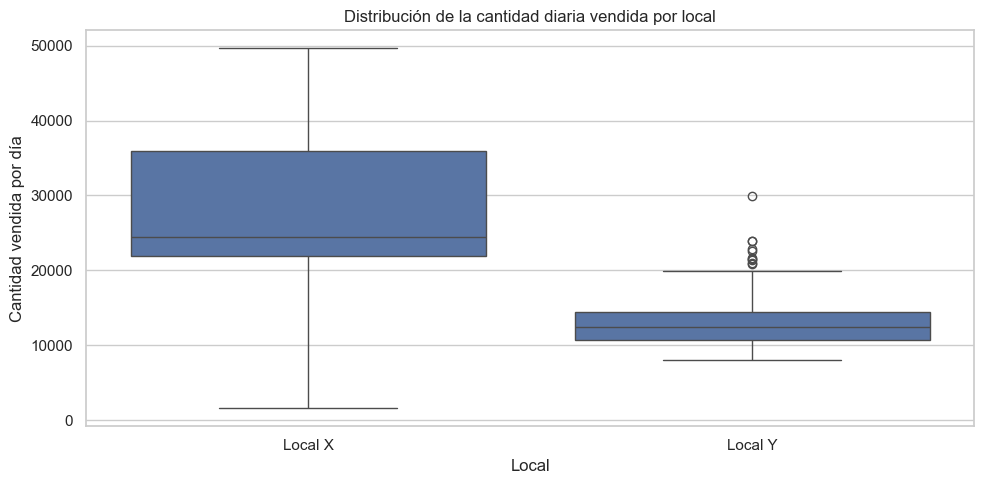

Interpretación: el boxplot permite comparar el nivel central y la dispersión de las ventas diarias entre locales.


In [17]:
# ============================================================
# 9.1 NUMÉRICA VS CATEGÓRICA: LOCAL
# ============================================================
plt.figure(figsize=(10,5))
sns.boxplot(data=daily_store, x="local", y="cantidad")
plt.title("Distribución de la cantidad diaria vendida por local")
plt.xlabel("Local")
plt.ylabel("Cantidad vendida por día")
plt.tight_layout()
plt.show()

print("Interpretación: el boxplot permite comparar el nivel central y la dispersión de las ventas diarias entre locales.")

In [18]:
# ============================================================
# 9.2 CATEGÓRICA VS CATEGÓRICA: LOCAL Y FIN DE SEMANA
# ============================================================
contingencia = pd.crosstab(
    daily_store["local"],
    daily_store["fin_de_semana"],
    normalize="index"
) * 100

contingencia.columns = ["Día hábil (%)", "Fin de semana (%)"]
display(contingencia.round(2))

print("Interpretación: esta tabla describe cómo se distribuyen las observaciones de cada local entre días hábiles y fines de semana.")

,Día hábil (%),Fin de semana (%)
local,,
Local X,71.38,28.62
Local Y,71.22,28.78


Interpretación: esta tabla describe cómo se distribuyen las observaciones de cada local entre días hábiles y fines de semana.


## 10. Visualizaciones requeridas

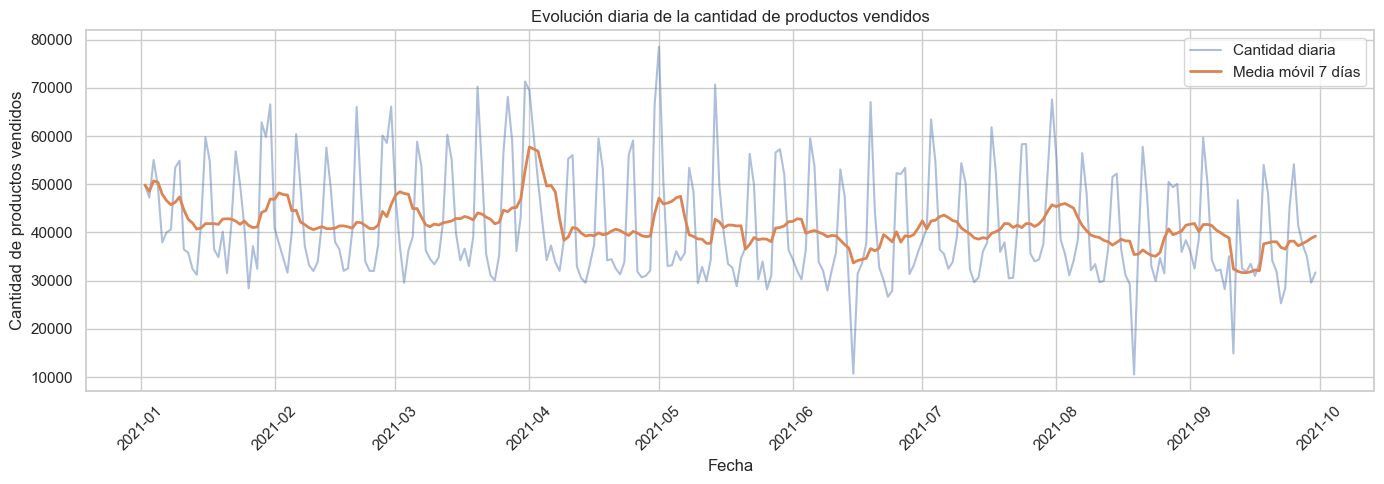

Interpretación: la serie temporal permite observar tendencia, variabilidad y posibles cambios de nivel. La media móvil suaviza fluctuaciones de corto plazo.


In [19]:
# ============================================================
# VISUALIZACIÓN 1 — SERIE TEMPORAL
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(daily["fecha_vta"], daily["cantidad"], alpha=.45, label="Cantidad diaria")
plt.plot(daily["fecha_vta"], daily["media_movil_7"], linewidth=2, label="Media móvil 7 días")
plt.title("Evolución diaria de la cantidad de productos vendidos")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de productos vendidos")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretación: la serie temporal permite observar tendencia, variabilidad y posibles cambios de nivel. La media móvil suaviza fluctuaciones de corto plazo.")

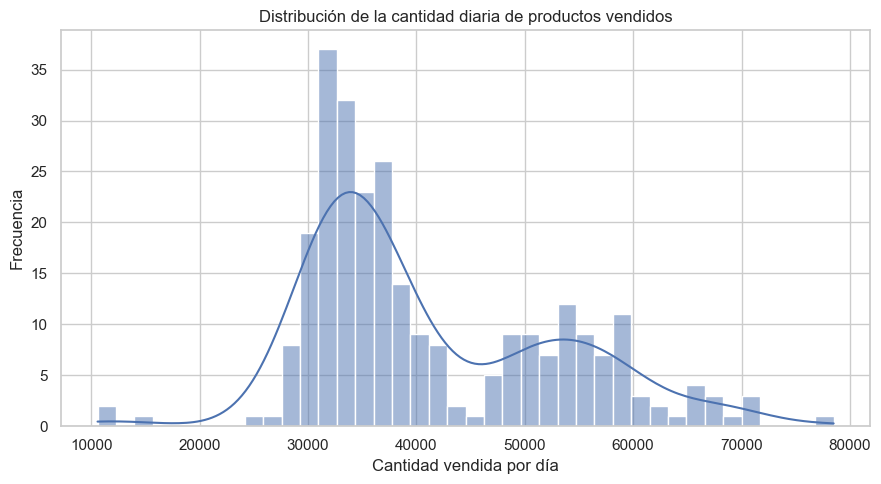

Interpretación: el histograma permite evaluar concentración, dispersión y asimetría de las ventas diarias.


In [20]:
# ============================================================
# VISUALIZACIÓN 2 — HISTOGRAMA
# ============================================================
plt.figure(figsize=(9,5))
sns.histplot(daily["cantidad"], bins=40, kde=True)
plt.title("Distribución de la cantidad diaria de productos vendidos")
plt.xlabel("Cantidad vendida por día")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Interpretación: el histograma permite evaluar concentración, dispersión y asimetría de las ventas diarias.")

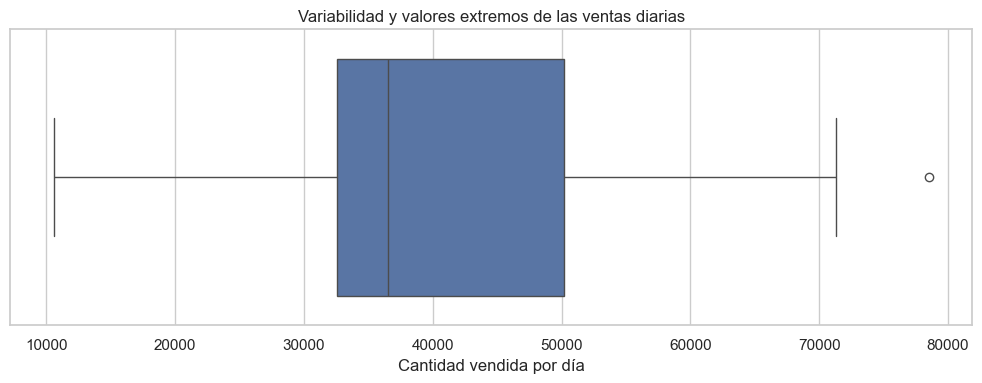

Interpretación: los puntos alejados del rango central son candidatos estadísticos a valores atípicos, pero no se consideran errores automáticamente.


In [21]:
# ============================================================
# VISUALIZACIÓN 3 — BOXPLOT
# ============================================================
plt.figure(figsize=(10,4))
sns.boxplot(x=daily["cantidad"])
plt.title("Variabilidad y valores extremos de las ventas diarias")
plt.xlabel("Cantidad vendida por día")
plt.tight_layout()
plt.show()

print("Interpretación: los puntos alejados del rango central son candidatos estadísticos a valores atípicos, pero no se consideran errores automáticamente.")

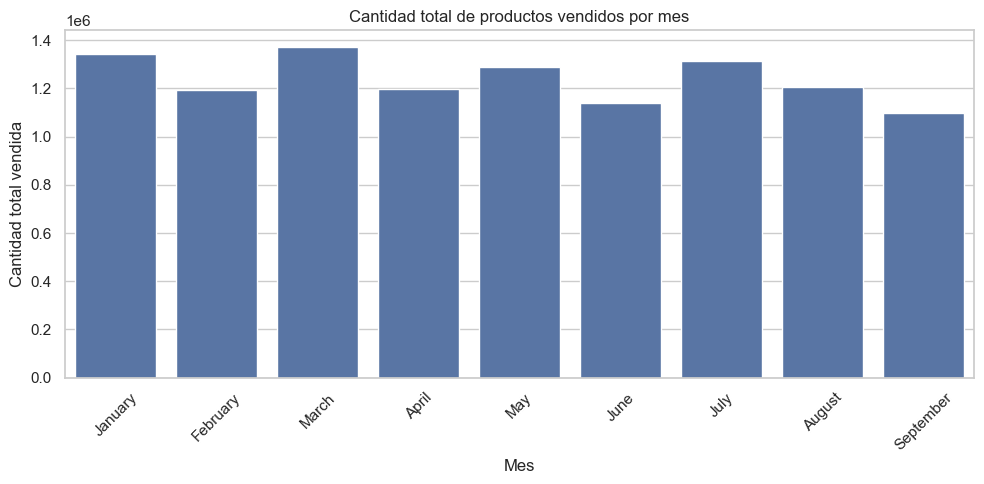

Interpretación: el gráfico compara el volumen total de ventas entre los meses del período estudiado.


In [22]:
# ============================================================
# VISUALIZACIÓN 4 — VENTAS POR MES
# ============================================================
mensual = daily.groupby(["mes","mes_nombre"], as_index=False)["cantidad"].sum()

plt.figure(figsize=(10,5))
sns.barplot(data=mensual, x="mes_nombre", y="cantidad")
plt.title("Cantidad total de productos vendidos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad total vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretación: el gráfico compara el volumen total de ventas entre los meses del período estudiado.")

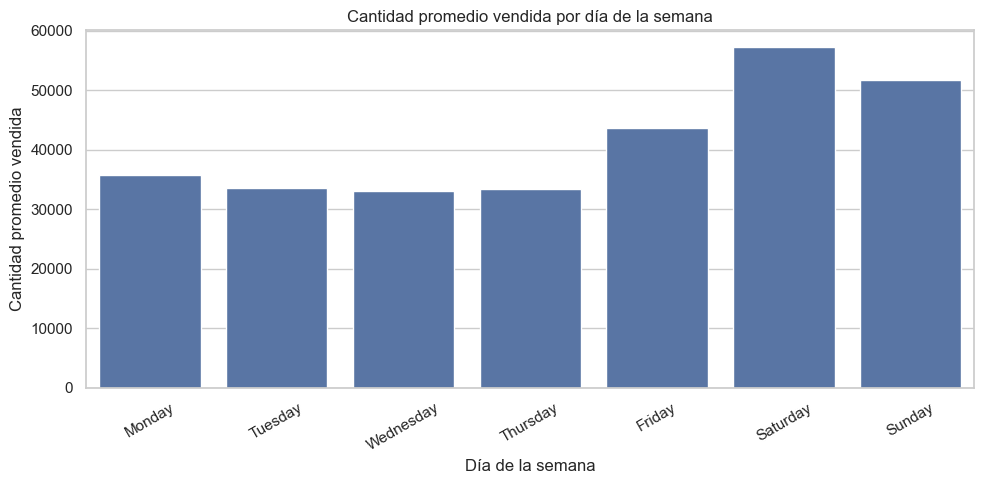

Interpretación: permite detectar diferencias descriptivas entre días, un posible factor de calendario que debe considerarse al estudiar el clima.


In [23]:
# ============================================================
# VISUALIZACIÓN 5 — DÍA DE SEMANA
# ============================================================
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
semana = daily.groupby("día_semana", as_index=False)["cantidad"].mean()
semana["orden"] = semana["día_semana"].map({d:i for i,d in enumerate(orden_dias)})
semana = semana.sort_values("orden")

plt.figure(figsize=(10,5))
sns.barplot(data=semana, x="día_semana", y="cantidad")
plt.title("Cantidad promedio vendida por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad promedio vendida")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Interpretación: permite detectar diferencias descriptivas entre días, un posible factor de calendario que debe considerarse al estudiar el clima.")

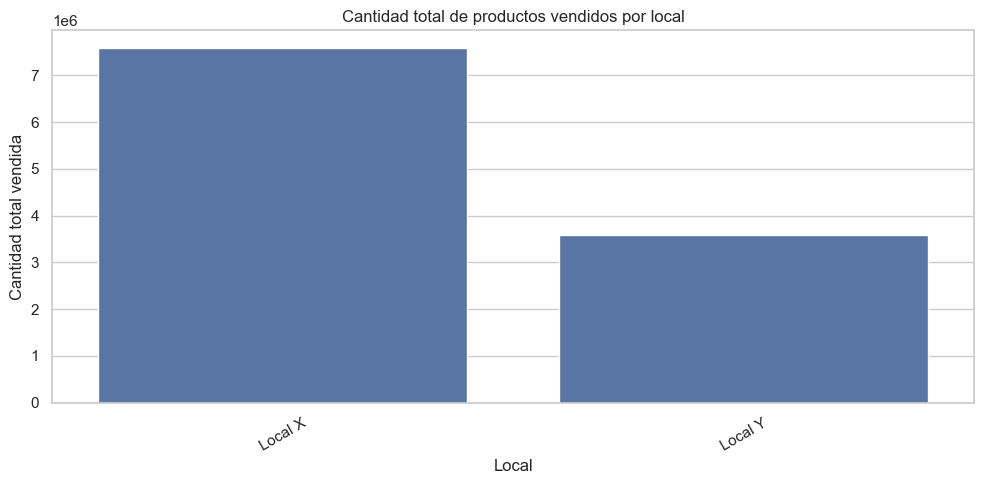

Interpretación: permite comparar el volumen acumulado de ventas y observar la heterogeneidad entre establecimientos.


In [24]:
# ============================================================
# VISUALIZACIÓN 6 — COMPARACIÓN ENTRE LOCALES
# ============================================================
local_resumen = daily_store.groupby("local", as_index=False)["cantidad"].sum().sort_values("cantidad", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=local_resumen, x="local", y="cantidad")
plt.title("Cantidad total de productos vendidos por local")
plt.xlabel("Local")
plt.ylabel("Cantidad total vendida")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Interpretación: permite comparar el volumen acumulado de ventas y observar la heterogeneidad entre establecimientos.")

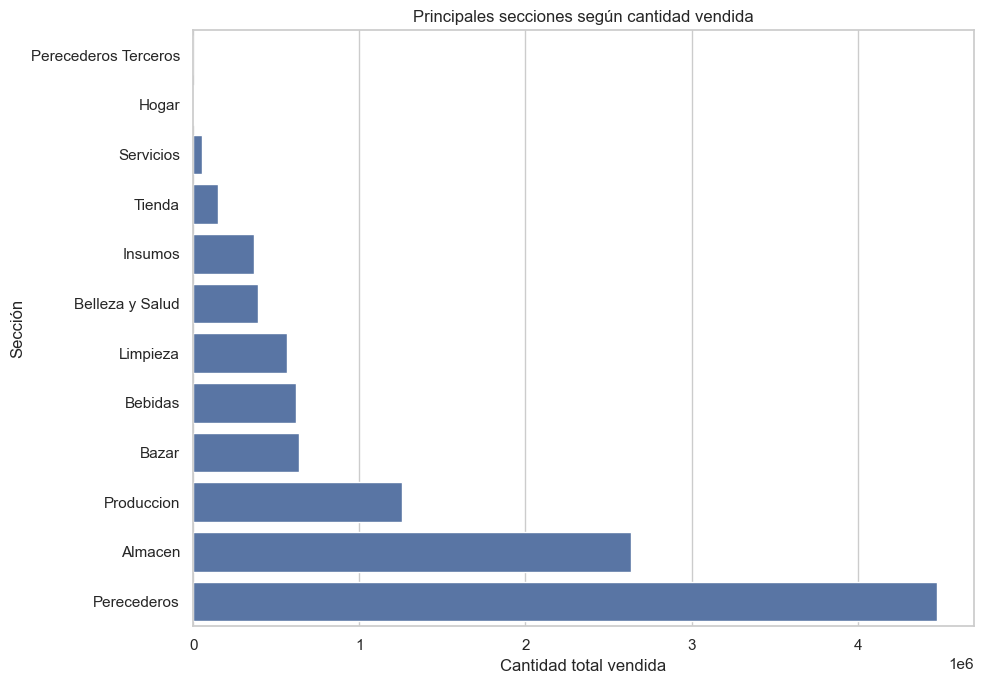

Interpretación: muestra qué secciones concentran mayor volumen y permite seleccionar segmentos relevantes para el análisis climático.


In [25]:
# ============================================================
# VISUALIZACIÓN 7 — SECCIONES
# ============================================================
section_parts = []

for chunk in pd.read_csv(
    CLEAN_PATH,
    usecols=["desc_secciones","cantidad"],
    chunksize=CHUNK_SIZE,
    low_memory=False
):
    chunk["desc_secciones"] = chunk["desc_secciones"].astype("string").str.strip()
    section_parts.append(
        chunk.groupby("desc_secciones", dropna=False, as_index=False)["cantidad"].sum()
    )

section_resumen = (
    pd.concat(section_parts, ignore_index=True)
    .groupby("desc_secciones", dropna=False, as_index=False)["cantidad"].sum()
    .sort_values("cantidad", ascending=False)
)

top_sections = section_resumen.head(15).sort_values("cantidad")

plt.figure(figsize=(10,7))
sns.barplot(data=top_sections, x="cantidad", y="desc_secciones")
plt.title("Principales secciones según cantidad vendida")
plt.xlabel("Cantidad total vendida")
plt.ylabel("Sección")
plt.tight_layout()
plt.show()

print("Interpretación: muestra qué secciones concentran mayor volumen y permite seleccionar segmentos relevantes para el análisis climático.")

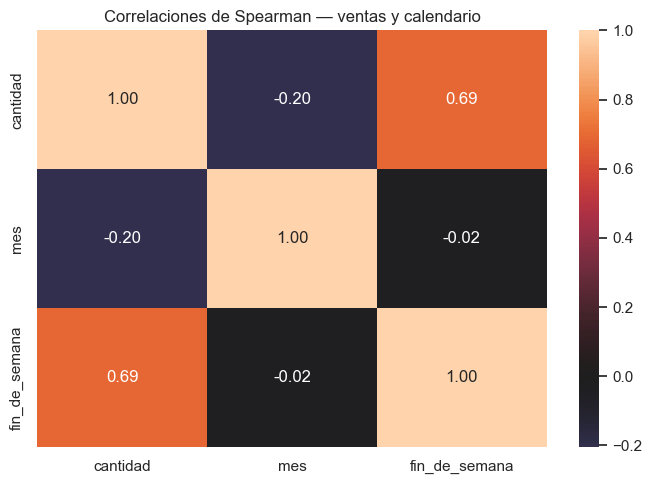

Interpretación: el mapa resume asociaciones monotónicas entre ventas y variables de calendario. La matriz final deberá incluir las variables climáticas.


In [26]:
# ============================================================
# VISUALIZACIÓN 8 — HEATMAP PRELIMINAR
# ============================================================
numeric = daily[["cantidad","mes","fin_de_semana"]].copy()
numeric["fin_de_semana"] = numeric["fin_de_semana"].astype(int)

corr_preliminar = numeric.corr(method="spearman")

plt.figure(figsize=(7,5))
sns.heatmap(corr_preliminar, annot=True, fmt=".2f", center=0)
plt.title("Correlaciones de Spearman — ventas y calendario")
plt.tight_layout()
plt.show()

print("Interpretación: el mapa resume asociaciones monotónicas entre ventas y variables de calendario. La matriz final deberá incluir las variables climáticas.")

## 11. Integración de datos climáticos

### Decisión metodológica

Como el CSV no contiene coordenadas ni una ubicación verificable para `Local X` y `Local Y`, el clima se incorpora mediante una **serie meteorológica diaria de referencia para Asunción, Paraguay**.

La integración se realizará mediante la clave:

**`fecha_vta`**

Esto es adecuado porque:

- las ventas se agregan a nivel **fecha + local**;
- el clima se obtiene a nivel **fecha**;
- una misma observación climática diaria puede relacionarse con las ventas de ambos locales en esa fecha;
- se utiliza `validate="many_to_one"` para comprobar que el cruce climático no genere duplicaciones.

Esta decisión no permite afirmar que el clima observado corresponda físicamente a cada establecimiento. Es una aproximación temporal y debe mencionarse como limitación.


In [27]:
# ============================================================
# 11.1 DESCARGA DESDE OPEN-METEO
# ============================================================
CLIMA_DIR = EXTERNAL_DIR / "open_meteo"
CLIMA_DIR.mkdir(parents=True, exist_ok=True)

CLIMATE_VARIABLES = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "relative_humidity_2m_mean"
]

CLIMATE_SOURCE_URL = "https://archive-api.open-meteo.com/v1/archive"

def descargar_clima_referencia(lat, lon):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": FECHA_INICIO.strftime("%Y-%m-%d"),
        "end_date": FECHA_FIN.strftime("%Y-%m-%d"),
        "daily": ",".join(CLIMATE_VARIABLES),
        "timezone": "America/Asuncion"
    }

    r = requests.get(CLIMATE_SOURCE_URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    clima = pd.DataFrame(data["daily"])
    clima["fecha_vta"] = pd.to_datetime(clima["time"])

    clima = clima[["fecha_vta"] + CLIMATE_VARIABLES].copy()
    clima["ubicacion_climatica_referencia"] = REFERENCE_LOCATION["nombre"]

    return clima

print("Descargando datos meteorológicos...")
clima = descargar_clima_referencia(
    REFERENCE_LOCATION["lat"],
    REFERENCE_LOCATION["lon"]
)

clima.to_csv(EXTERNAL_DIR / "clima_diario_referencia.csv", index=False)

print("Ubicación:", REFERENCE_LOCATION["nombre"])
print("Filas climáticas:", len(clima))
print("Fecha mínima:", clima["fecha_vta"].min().date())
print("Fecha máxima:", clima["fecha_vta"].max().date())
print("Duplicados por fecha:", clima.duplicated("fecha_vta").sum())

display(clima.head())


Descargando datos meteorológicos...
Ubicación: Asunción, Paraguay
Filas climáticas: 272
Fecha mínima: 2021-01-02
Fecha máxima: 2021-09-30
Duplicados por fecha: 0


,fecha_vta,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,ubicacion_climatica_referencia
0,2021-01-02,26.9,33.1,19.9,0.0,63,"Asunción, Paraguay"
1,2021-01-03,28.3,34.5,22.3,0.0,57,"Asunción, Paraguay"
2,2021-01-04,27.0,31.9,24.0,1.4,72,"Asunción, Paraguay"
3,2021-01-05,25.5,29.4,23.3,45.2,85,"Asunción, Paraguay"
4,2021-01-06,26.4,31.6,22.4,5.7,83,"Asunción, Paraguay"


In [28]:
# ============================================================
# 11.2 AUDITORÍA Y CRUCE VENTAS + CLIMA
# ============================================================
print("Filas ventas antes del cruce:", len(daily_store))
print("Filas clima:", len(clima))

print("Fechas climáticas duplicadas:", clima.duplicated("fecha_vta").sum())

analitico = daily_store.merge(
    clima,
    on="fecha_vta",
    how="left",
    validate="many_to_one",
    indicator=True
)

no_apareados = (analitico["_merge"] != "both").sum()
pct_no_apareados = no_apareados / len(analitico) * 100

print("Filas después del cruce:", len(analitico))
print("Filas no apareadas:", no_apareados)
print(f"Porcentaje no apareadas: {pct_no_apareados:.2f}%")

if len(analitico) != len(daily_store):
    raise ValueError(
        "El cruce alteró la cantidad de filas. "
        "Revisar la granularidad o las claves."
    )

analitico.drop(columns="_merge", inplace=True)

analitico.to_csv(
    PROCESSED_DIR / "ventas_clima_diarias_por_local.csv",
    index=False
)

display(analitico.head())


Filas ventas antes del cruce: 540
Filas clima: 272
Fechas climáticas duplicadas: 0
Filas después del cruce: 540
Filas no apareadas: 0
Porcentaje no apareadas: 0.00%


,fecha_vta,local,cantidad,año,mes,mes_nombre,día_semana,fin_de_semana,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,relative_humidity_2m_mean,ubicacion_climatica_referencia
0,2021-01-02,Local X,33774.6752,2021,1,January,Saturday,True,26.9,33.1,19.9,0.0,63,"Asunción, Paraguay"
1,2021-01-02,Local Y,16053.6385,2021,1,January,Saturday,True,26.9,33.1,19.9,0.0,63,"Asunción, Paraguay"
2,2021-01-03,Local X,34455.6471,2021,1,January,Sunday,True,28.3,34.5,22.3,0.0,57,"Asunción, Paraguay"
3,2021-01-03,Local Y,12785.4970,2021,1,January,Sunday,True,28.3,34.5,22.3,0.0,57,"Asunción, Paraguay"
4,2021-01-04,Local X,36839.1173,2021,1,January,Monday,False,27.0,31.9,24.0,1.4,72,"Asunción, Paraguay"


### Auditoría de integración

La clave de integración es **`fecha_vta`**.

El clima tiene una única fila por fecha, mientras que las ventas tienen una fila por **fecha + local**. Por eso, al cruzar, una misma observación meteorológica puede asociarse con ambos locales en la misma fecha.

La auditoría comprueba:

1. cantidad de filas antes del cruce;
2. cantidad de filas después del cruce;
3. duplicados en la fuente climática;
4. registros de ventas sin correspondencia climática;
5. que el cruce `many_to_one` no genere duplicación accidental.

**Interpretación:** el clima utilizado representa una condición meteorológica de referencia común para el período, no el clima específico de cada establecimiento.


## 12. Análisis bivariado clima–ventas

In [29]:
# ============================================================
# 12.1 CORRELACIONES PEARSON Y SPEARMAN
# ============================================================
clima_cols = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "relative_humidity_2m_mean"
]

datos_corr = analitico[["cantidad"] + clima_cols].dropna()

pearson = (
    datos_corr.corr(method="pearson")["cantidad"]
    .drop("cantidad")
    .sort_values()
)

spearman = (
    datos_corr.corr(method="spearman")["cantidad"]
    .drop("cantidad")
    .sort_values()
)

tabla_corr = pd.DataFrame({
    "Pearson": pearson,
    "Spearman": spearman
})

display(tabla_corr)

print(
    "Interpretación: Pearson resume asociación lineal y Spearman asociación "
    "monotónica. Ninguna de las dos implica causalidad."
)


,Pearson,Spearman
precipitation_sum,0.032802,0.004213
relative_humidity_2m_mean,0.031903,0.012591
temperature_2m_max,0.032009,0.036904
temperature_2m_mean,0.033991,0.032573
temperature_2m_min,0.025840,0.019691


Interpretación: Pearson resume asociación lineal y Spearman asociación monotónica. Ninguna de las dos implica causalidad.


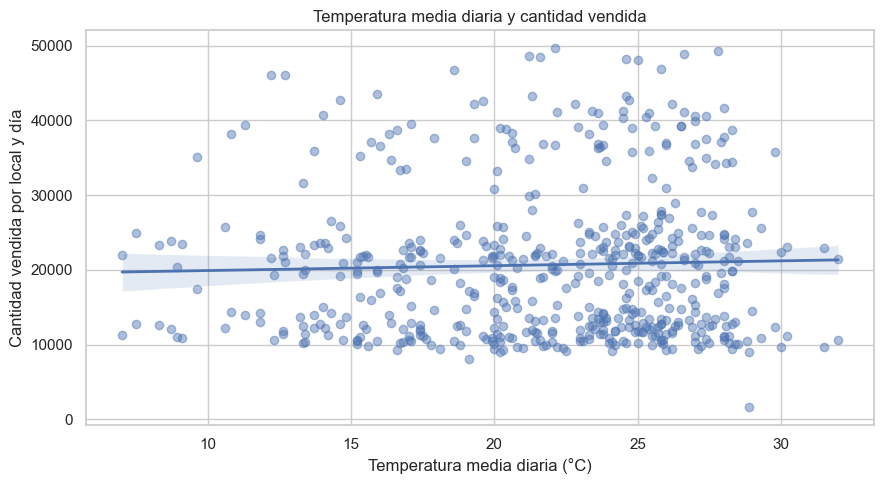

Interpretación: la asociación monotónica observada entre temperatura de referencia y ventas es rho=0.033.


In [30]:
# ============================================================
# VISUALIZACIÓN 9 — TEMPERATURA VS VENTAS
# ============================================================
plt.figure(figsize=(9,5))

sns.regplot(
    data=analitico,
    x="temperature_2m_mean",
    y="cantidad",
    scatter_kws={"alpha":0.45},
    line_kws={"linewidth":2}
)

plt.title("Temperatura media diaria y cantidad vendida")
plt.xlabel("Temperatura media diaria (°C)")
plt.ylabel("Cantidad vendida por local y día")
plt.tight_layout()
plt.show()

rho = analitico[
    ["temperature_2m_mean","cantidad"]
].corr(method="spearman").iloc[0,1]

print(
    f"Interpretación: la asociación monotónica observada entre temperatura "
    f"de referencia y ventas es rho={rho:.3f}."
)


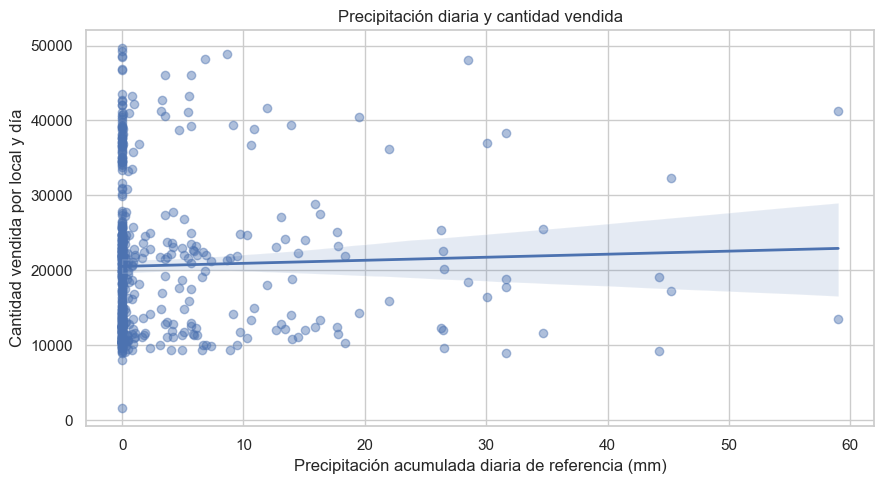

Interpretación: la asociación monotónica observada entre precipitación de referencia y ventas es rho=0.004.


In [31]:
# ============================================================
# VISUALIZACIÓN 10 — PRECIPITACIÓN VS VENTAS
# ============================================================
plt.figure(figsize=(9,5))

sns.regplot(
    data=analitico,
    x="precipitation_sum",
    y="cantidad",
    scatter_kws={"alpha":0.45},
    line_kws={"linewidth":2}
)

plt.title("Precipitación diaria y cantidad vendida")
plt.xlabel("Precipitación acumulada diaria de referencia (mm)")
plt.ylabel("Cantidad vendida por local y día")
plt.tight_layout()
plt.show()

rho = analitico[
    ["precipitation_sum","cantidad"]
].corr(method="spearman").iloc[0,1]

print(
    f"Interpretación: la asociación monotónica observada entre precipitación "
    f"de referencia y ventas es rho={rho:.3f}."
)


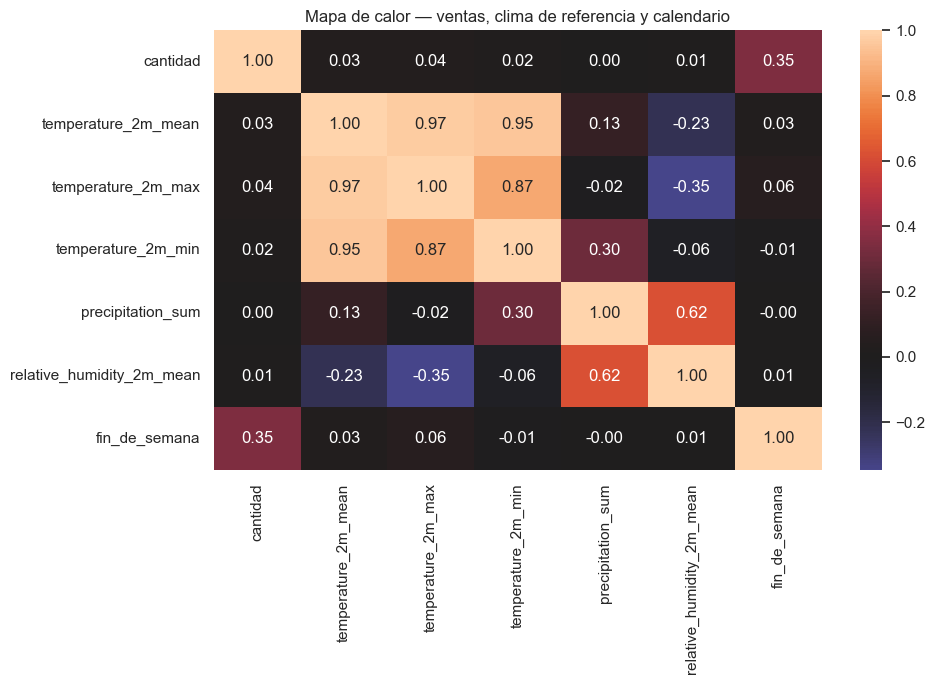

Interpretación: el mapa permite comparar la intensidad y dirección de las asociaciones monotónicas entre ventas, clima de referencia y calendario.


In [32]:
# ============================================================
# VISUALIZACIÓN 11 — HEATMAP FINAL
# ============================================================
cols = [
    "cantidad",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "relative_humidity_2m_mean",
    "fin_de_semana"
]

matriz = analitico[cols].copy()
matriz["fin_de_semana"] = matriz["fin_de_semana"].astype(int)

corr_final = matriz.corr(method="spearman")

plt.figure(figsize=(10,7))
sns.heatmap(corr_final, annot=True, fmt=".2f", center=0)

plt.title("Mapa de calor — ventas, clima de referencia y calendario")
plt.tight_layout()
plt.show()

print(
    "Interpretación: el mapa permite comparar la intensidad y dirección "
    "de las asociaciones monotónicas entre ventas, clima de referencia y calendario."
)


## 13. Patrones, anomalías e hipótesis preliminares

In [33]:
# ============================================================
# 13.1 EVIDENCIA AUTOMÁTICA PARA PATRONES
# ============================================================
print("TOP 5 DÍAS POR CANTIDAD VENDIDA")
display(daily.nlargest(5, "cantidad")[["fecha_vta","cantidad"]])

print("\nBOTTOM 5 DÍAS POR CANTIDAD VENDIDA")
display(daily.nsmallest(5, "cantidad")[["fecha_vta","cantidad"]])

print("\nMESES")
display(mensual.sort_values("cantidad", ascending=False))

print("\nLOCALES")
display(local_resumen)

TOP 5 DÍAS POR CANTIDAD VENDIDA


,fecha_vta,cantidad
118,2021-05-01,78503.3404
88,2021-03-31,71311.1720
131,2021-05-14,70679.0692
77,2021-03-20,70252.0144
89,2021-04-01,69456.0064



BOTTOM 5 DÍAS POR CANTIDAD VENDIDA


,fecha_vta,cantidad
228,2021-08-19,10569.8060
163,2021-06-15,10709.7140
251,2021-09-11,14900.7020
262,2021-09-22,25313.6150
171,2021-06-23,26660.8504



MESES


,mes,mes_nombre,cantidad
2,3,March,1.372264e+06
0,1,January,1.341581e+06
6,7,July,1.315024e+06
4,5,May,1.288839e+06
7,8,August,1.207626e+06
3,4,April,1.199734e+06
1,2,February,1.195056e+06
5,6,June,1.137833e+06
8,9,September,1.100249e+06



LOCALES


,local,cantidad
0,Local X,7.582556e+06
1,Local Y,3.575650e+06


In [34]:
# ============================================================
# 13.2 HIPÓTESIS PRELIMINARES
# ============================================================
hipotesis = pd.DataFrame([
    ["H1", "La temperatura media diaria presenta una asociación con la cantidad vendida."],
    ["H2", "La precipitación acumulada diaria presenta una asociación con la cantidad vendida."],
    ["H3", "La cantidad vendida difiere según el día de la semana."],
    ["H4", "La cantidad vendida difiere entre los locales."],
    ["H5", "La asociación entre clima y cantidad vendida puede variar según el local o sección."]
], columns=["hipótesis","formulación"])

display(hipotesis)
print("Estas hipótesis son preliminares. En la Fase 2 deberán transformarse en contrastes formales y sus pruebas deberán justificarse.")

,hipótesis,formulación
0,H1,La temperatura media diaria presenta una asoci...
1,H2,La precipitación acumulada diaria presenta una...
2,H3,La cantidad vendida difiere según el día de la...
3,H4,La cantidad vendida difiere entre los locales.
4,H5,La asociación entre clima y cantidad vendida p...


Estas hipótesis son preliminares. En la Fase 2 deberán transformarse en contrastes formales y sus pruebas deberán justificarse.


## 14. Conclusión de la Fase 1 — borrador reproducible

La conclusión definitiva debe redactarse después de ejecutar todas las celdas y revisar los gráficos. La siguiente celda genera un resumen numérico para que la redacción se base en evidencia, no en afirmaciones genéricas.

In [35]:
# ============================================================
# 14.1 RESUMEN FINAL
# ============================================================
print("="*70)
print("RESUMEN FINAL DE LA FASE 1")
print("="*70)

print(f"Registros originales: {total_filas:,}")
print(f"Registros dentro del período: {filas_periodo:,}")
print(f"Período: {FECHA_INICIO.date()} a {FECHA_FIN.date()}")
print(f"Días agregados: {len(daily):,}")
print(f"Locales: {daily_store['local'].nunique():,}")
print(f"Secciones: {section_resumen['desc_secciones'].nunique():,}")
print(f"Cantidad total agregada: {daily['cantidad'].sum():,.2f}")
print(f"Negativos: {cantidad_negativa:,} ({cantidad_negativa/total_filas*100:.2f}%)")
print(f"Faltantes con alguna columna vacía: {len(registros_faltantes):,}")
print(f"Grupos de duplicados exactos: {grupos_duplicados:,}")
print(f"Filas adicionales duplicadas: {filas_duplicadas_adicionales:,}")

print("\nIntegración climática: realizada")
print(f"Ubicación climática de referencia: {REFERENCE_LOCATION['nombre']}")
print(f"Filas analíticas clima-ventas: {len(analitico):,}")
print("Advertencia: la ubicación climática es una referencia temporal y no la ubicación real verificada de los locales.")


RESUMEN FINAL DE LA FASE 1
Registros originales: 9,447,662
Registros dentro del período: 9,447,662
Período: 2021-01-02 a 2021-09-30
Días agregados: 271
Locales: 2
Secciones: 12
Cantidad total agregada: 11,158,206.72
Negativos: 67,523 (0.71%)
Faltantes con alguna columna vacía: 6
Grupos de duplicados exactos: 1,337,516
Filas adicionales duplicadas: 4,335,413

Integración climática: realizada
Ubicación climática de referencia: Asunción, Paraguay
Filas analíticas clima-ventas: 540
Advertencia: la ubicación climática es una referencia temporal y no la ubicación real verificada de los locales.


### Conclusión para el informe

Al ejecutar el notebook, esta sección debe convertirse en una conclusión de 1–2 páginas. Debe incluir:

1. cómo se comportaron las ventas en el período;
2. diferencias temporales, por local y por sección;
3. principales problemas de calidad y decisiones de limpieza;
4. tratamiento de negativos, duplicados y valores extremos;
5. evidencia descriptiva sobre temperatura, precipitación y humedad;
6. limitaciones: ausencia de ID transaccional, posible dependencia temporal, naturaleza agregada de `cantidad` y, especialmente, **ausencia de ubicación geográfica verificable de los locales**;
7. explicación de que el clima utilizado corresponde a una **ubicación meteorológica de referencia (Asunción, Paraguay)** y no debe interpretarse como clima específico de Local X o Local Y;
8. tres a cinco hipótesis que pasarán a la Fase 2.

**No afirmar causalidad.** Una correlación o asociación descriptiva no demuestra que el clima cause cambios en las ventas.


## 15. Exportación

In [36]:
# ============================================================
# 15.1 EXPORTACIÓN DE TABLAS Y RESÚMENES
# ============================================================
estadisticos.to_csv(TABLES_DIR / "estadisticos_ventas_diarias.csv", index=False)
resumen_calidad.to_csv(TABLES_DIR / "resumen_calidad.csv", index=False)
cardinalidad.to_csv(TABLES_DIR / "cardinalidad.csv", index=False)
section_resumen.to_csv(TABLES_DIR / "ventas_por_seccion.csv", index=False)
mensual.to_csv(TABLES_DIR / "ventas_por_mes.csv", index=False)
local_resumen.to_csv(TABLES_DIR / "ventas_por_local.csv", index=False)
hipotesis.to_csv(TABLES_DIR / "hipotesis_preliminares.csv", index=False)
tabla_corr.to_csv(TABLES_DIR / "correlaciones_clima_ventas.csv")

print("Archivos de tablas generados:")
for p in sorted(TABLES_DIR.glob("*")):
    print("-", p.name, f"({p.stat().st_size/1024**2:.2f} MB)")

print("\nDataset limpio:", CLEAN_PATH)
print("Dataset diario:", PROCESSED_DIR / "ventas_diarias.csv")
print("Dataset diario por local:", PROCESSED_DIR / "ventas_diarias_por_local.csv")
print("Dataset clima-ventas:", PROCESSED_DIR / "ventas_clima_diarias_por_local.csv")


Archivos de tablas generados:
- bitacora_limpieza.csv (0.00 MB)
- cardinalidad.csv (0.00 MB)
- correlaciones_clima_ventas.csv (0.00 MB)
- diccionario_datos_original.csv (0.00 MB)
- estadisticos_ventas_diarias.csv (0.00 MB)
- hipotesis_preliminares.csv (0.00 MB)
- resumen_calidad.csv (0.00 MB)
- ventas_por_local.csv (0.00 MB)
- ventas_por_mes.csv (0.00 MB)
- ventas_por_seccion.csv (0.00 MB)

Dataset limpio: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\processed\ventas_limpias.csv
Dataset diario: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\processed\ventas_diarias.csv
Dataset diario por local: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\processed\ventas_diarias_por_local.csv
Dataset clima-ventas: c:\Users\HOME\Desktop\DATA_SCIENCE_PROJECT\FASE1_ENTREGABLE\ESRUCTURA ENTREGA\proyecto-data-science\data\processed